## Potential talents

### Data Description:

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

### Attributes:
id : unique identifier for candidate (numeric)

job_title : job title for candidate (text)

location : geographical location for candidate (text)

connections: number of connections candidate has, 500+ means over 500 (text)

### Output (desired target):
fit - how fit the candidate is for the role? (numeric, probability between 0-1)

Keywords: “Aspiring human resources” or “seeking human resources”

### Goal(s):

Predict how fit the candidate is based on their available information (variable fit)

### Success Metric(s):

Rank candidates based on a fitness score.

Re-rank candidates when a candidate is starred.

### Current Challenges:

We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.

How can we filter out candidates which in the first place should not be in this list?

Can we determine a cut-off point that would work for other roles without losing high potential candidates?

Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import re

In [2]:
talents = pd.read_csv("potential-talents.csv", index_col = "id" )

In [3]:
talents.shape

(104, 4)

In [4]:
talents.head()

,job_title,location,connection,fit
id,,,,
1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [5]:
talents.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 1 to 104
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   job_title   104 non-null    str    
 1   location    104 non-null    str    
 2   connection  104 non-null    str    
 3   fit         0 non-null      float64
dtypes: float64(1), str(3)
memory usage: 3.4 KB


In [6]:
talents.describe()

,fit
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [7]:
talents.dtypes

job_title         str
location          str
connection        str
fit           float64
dtype: object

In [8]:
# Clean text
def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

In [9]:
# Convert connections column from text to numeric
def str_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(",", "")
    if "500+" in x:
        return 500
    digits = re.findall(r"\d+", x)
    return int(digits[0]) if digits else np.nan

In [10]:
# Clean text columns
for col in ["job_title", "location"]:
    if col in talents.columns:
        talents[col] = talents[col].apply(clean_text)

In [11]:
# Parse connections
if "connection" in talents.columns:
    talents["connection_num"] = talents["connection"].apply(str_to_num)

In [12]:
talents.head()

,job_title,location,connection,fit,connection_num
id,,,,,
1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN,85
2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN,500
3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44
4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN,500
5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN,500


In [13]:
# Duplicate analysis

# Full-row duplicates
full_dupes = talents.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 51


In [14]:
# Duplicates ignoring unique id
subset_cols = [c for c in talents.columns if c != "id"]
if subset_cols:
    logical_dupes = talents.duplicated(subset=subset_cols).sum()
    print(f"Duplicate rows excluding 'id': {logical_dupes}")

Duplicate rows excluding 'id': 51


In [15]:
# Duplicate candidate signatures by job_title + location + connections
candidate_key_cols = [c for c in ["job_title", "location", "connections"] if c in talents.columns]
if candidate_key_cols:
    duplicate_groups = (
        talents.groupby(candidate_key_cols)
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=False)
    )
    print("\nTop repeated candidate profiles:")
    print(duplicate_groups.head(15))


Top repeated candidate profiles:
                                            job_title  \
0   2019 C.T. Bauer College of Business Graduate (...   
49  Student at Humber College and Aspiring Human R...   
8               Aspiring Human Resources Professional   
37             People Development Coordinator at Ryan   
11                Aspiring Human Resources Specialist   
20                               HR Senior Specialist   
35  Native English Teacher at EPIK (English Progra...   
21  Human Resources Coordinator at InterContinenta...   
40  SVP, CHRO, Marketing & Communications, CSR Off...   
41  Seeking Human Resources HRIS and Generalist Po...   
48                      Student at Chapman University   
2     Advisory Board Member at Celal Bayar University   
4   Aspiring Human Resources Management student se...   
42              Seeking Human Resources Opportunities   
1   Admissions Representative at Community medical...   

                               location  count  
0   

In [16]:
# Missing values report

talents.isnull().sum()

job_title           0
location            0
connection          0
fit               104
connection_num      0
dtype: int64

In [17]:
# Feature engineering

keywords = ["aspiring human resources", "seeking human resources", "human resources", "hr", "recruiting", "talent", "people development"]

In [18]:
def contains_phrase(text, phrase):
    if pd.isna(text):
        return 0
    return int(phrase.lower() in text.lower())

def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_chars(text):
    if pd.isna(text):
        return 0
    return len(str(text))

def keyword_match_score(text, keyword_list):
    if pd.isna(text):
        return 0
    txt = text.lower()
    return sum(1 for kw in keyword_list if kw in txt)

In [19]:
talents["job_title_word_count"] = talents["job_title"].apply(count_words)
talents["keyword_match_score"] = talents["job_title"].apply(lambda x: keyword_match_score(x, keywords))
talents["has_aspiring"] = talents["job_title"].apply(lambda x: contains_phrase(x, "aspiring"))
talents["has_seeking"] = talents["job_title"].apply(lambda x: contains_phrase(x, "seeking"))

In [20]:
talents["location_word_count"] = talents["location"].apply(count_words)
talents["has_texas"] = talents["location"].apply(lambda x: int("texas" in str(x).lower()) if pd.notna(x) else 0)
talents["has_california"] = talents["location"].apply(lambda x: int("california" in str(x).lower()) if pd.notna(x) else 0)
talents["has_new_york"] = talents["location"].apply(lambda x: int("new york" in str(x).lower()) if pd.notna(x) else 0)

In [21]:
talents.head()

,job_title,location,connection,fit,connection_num,job_title_word_count,keyword_match_score,has_aspiring,has_seeking,location_word_count,has_texas,has_california,has_new_york
id,,,,,,,,,,,,,
1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN,85,15,2,1,0,2,1,0,0
2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN,500,9,0,0,0,1,0,0,0
3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,44,4,2,1,0,4,0,0,0
4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN,500,5,1,0,0,2,1,0,0
5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN,500,7,0,0,0,2,0,0,0


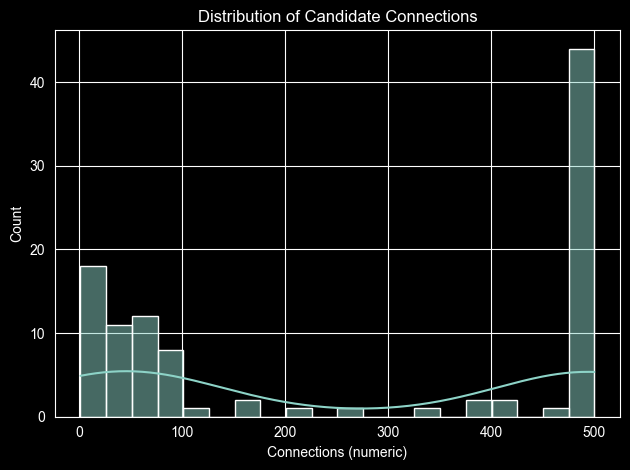

In [22]:
# Univariate analysis

sns.histplot(talents["connection_num"].dropna(), bins=20, kde=True)
plt.title("Distribution of Candidate Connections")
plt.xlabel("Connections (numeric)")
plt.tight_layout()
plt.show()

A large proportion of candidates have 500 or more connections.

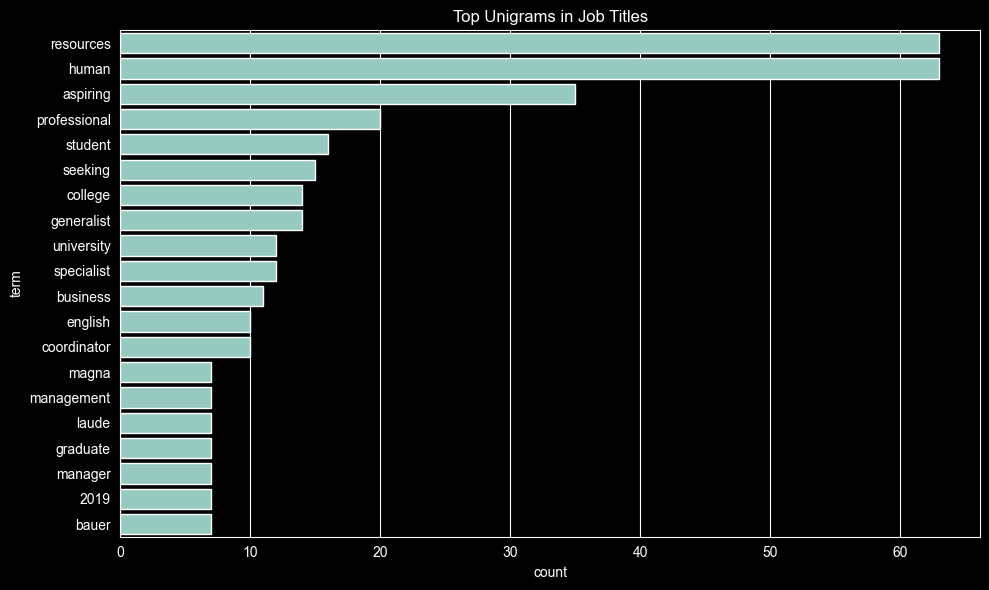

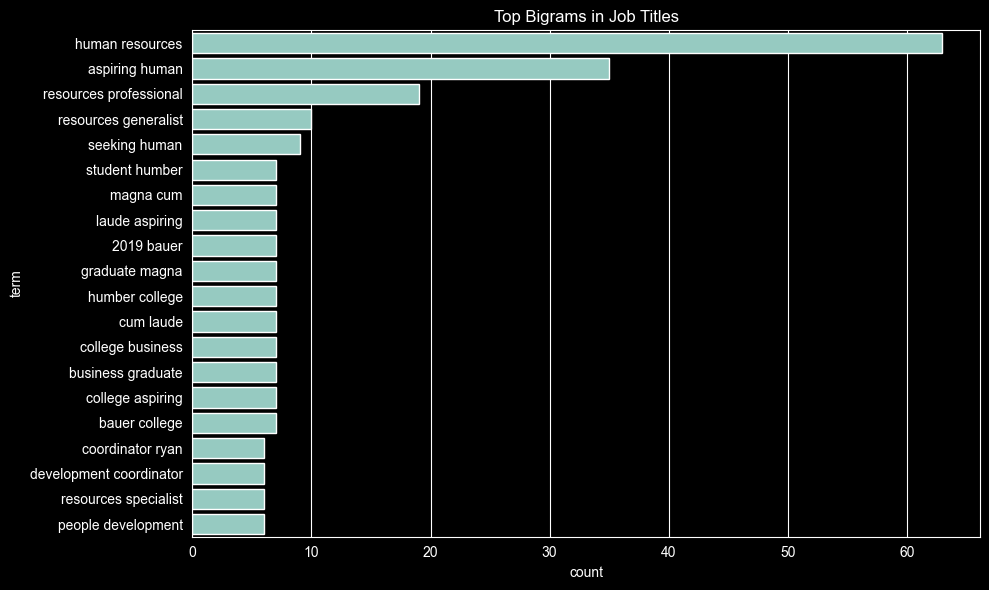

In [23]:
# Text analysis

text_series = talents["job_title"].dropna().astype(str)

for ngram_range, title in [((1, 1), "Top Unigrams in Job Titles"), ((2, 2), "Top Bigrams in Job Titles")]:
    vectorizer = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=1)
    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())

    top_n = 20
    idx = counts.argsort()[::-1][:top_n]
    top_terms = pd.DataFrame({"term": vocab[idx], "count": counts[idx]})

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_terms, x="count", y="term")
    plt.title(title)
    plt.tight_layout()
    plt.show()

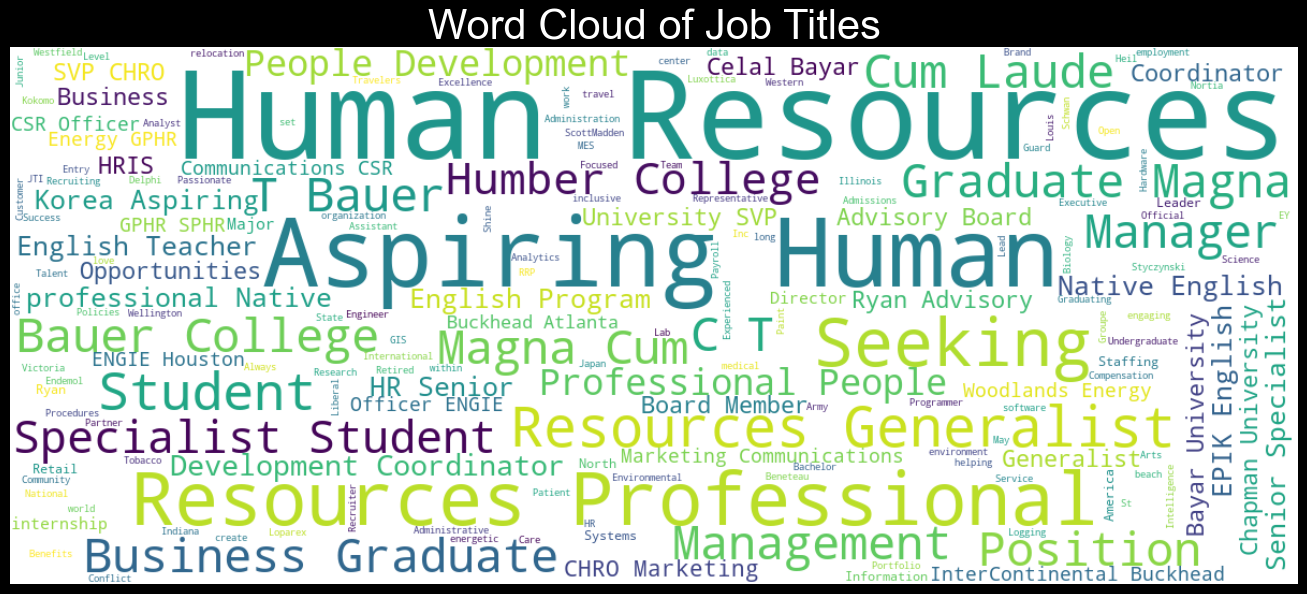

In [24]:
# Generate wordcloud

full_text = " ".join(text_series.tolist())
wordcloud = WordCloud(width=1200, height=500, background_color="white").generate(full_text)
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Job Titles", size=30)
plt.tight_layout()
plt.show()

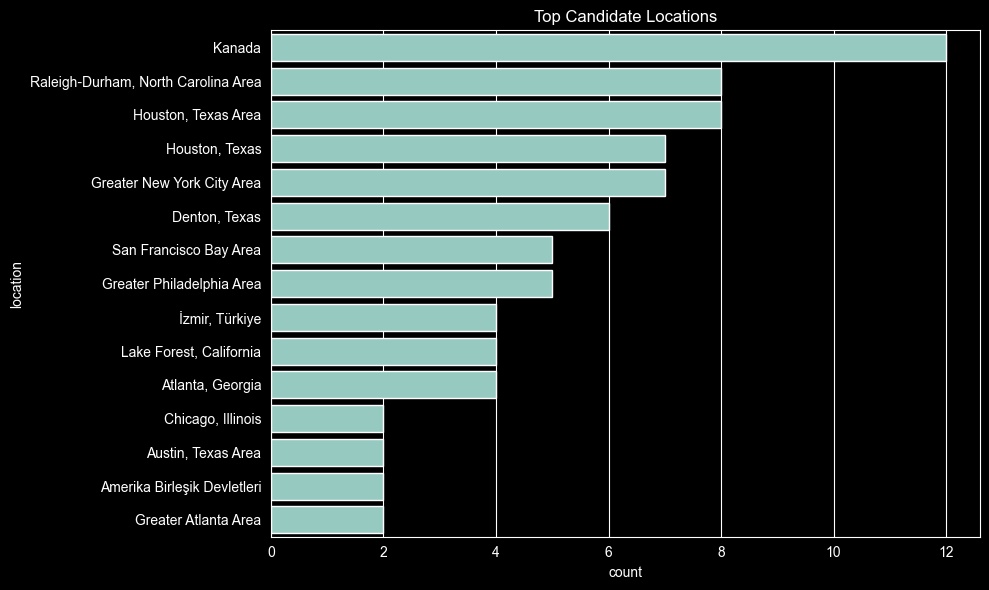

In [25]:
top_locations = talents["location"].value_counts().head(15).reset_index()
top_locations.columns = ["location", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_locations, x="count", y="location")
plt.title("Top Candidate Locations")
plt.tight_layout()
plt.show()

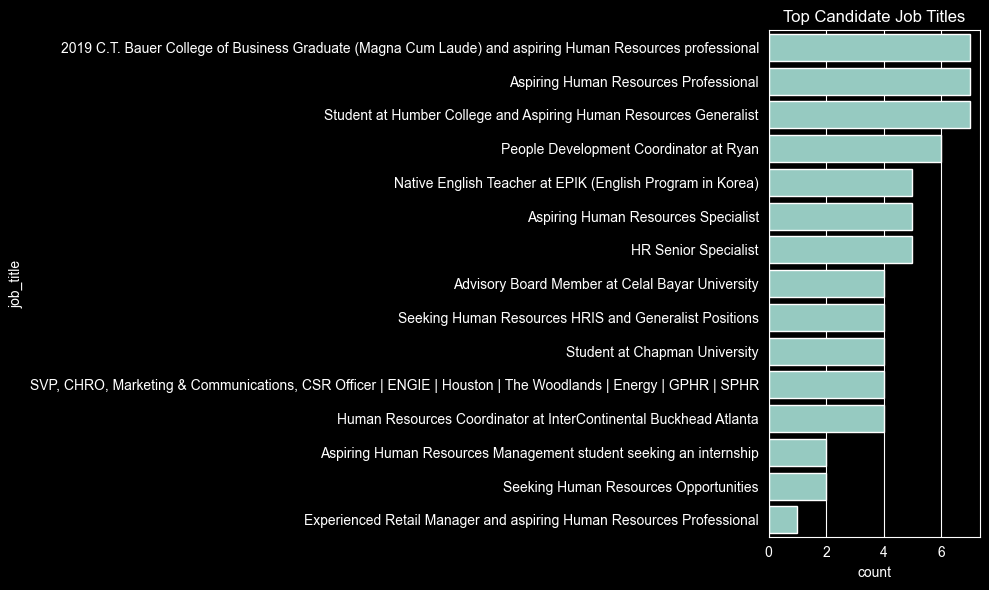

In [26]:
top_locations = talents["job_title"].value_counts().head(15).reset_index()
top_locations.columns = ["job_title", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_locations, x="count", y="job_title")
plt.title("Top Candidate Job Titles")
plt.tight_layout()
plt.show()

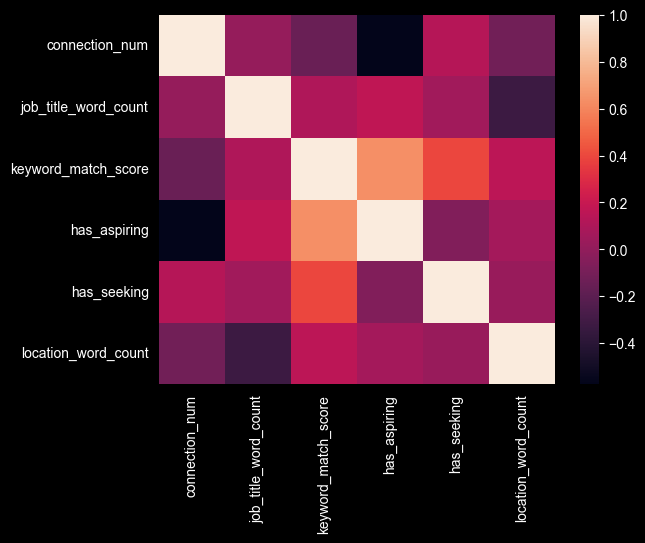

In [27]:
# Correlation in numeric columns

num_cols = ["connection_num", "job_title_word_count", "keyword_match_score", "has_aspiring", "has_seeking", 
            "location_word_count"]

corr = talents[num_cols].corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [28]:
round(corr, 3)

,connection_num,job_title_word_count,keyword_match_score,has_aspiring,has_seeking,location_word_count
connection_num,1.000,0.012,-0.147,-0.576,0.131,-0.117
job_title_word_count,0.012,1.000,0.102,0.167,0.058,-0.324
keyword_match_score,-0.147,0.102,1.000,0.633,0.396,0.152
has_aspiring,-0.576,0.167,0.633,1.000,-0.061,0.068
has_seeking,0.131,0.058,0.396,-0.061,1.000,0.022
location_word_count,-0.117,-0.324,0.152,0.068,0.022,1.000


Few important obeservations:
1. A candidate's number of connections has a significant negative correlation with the word "aspiring" in the job title.
2. A candidate's keyword match score has a significant positive correlation with words "aspiring" and "seeking" in the job title.
3. A candidate's location word count has a significant negative correlation with the corresponding job title word count.

In [29]:
# Save EDA output to csv

output_file = "potential_talent_eda_output.csv"
talents.to_csv(output_file, index=False)